Saving bank-additional-full.csv to bank-additional-full.csv
Задание 1. Загрузка и профилирование данных

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15

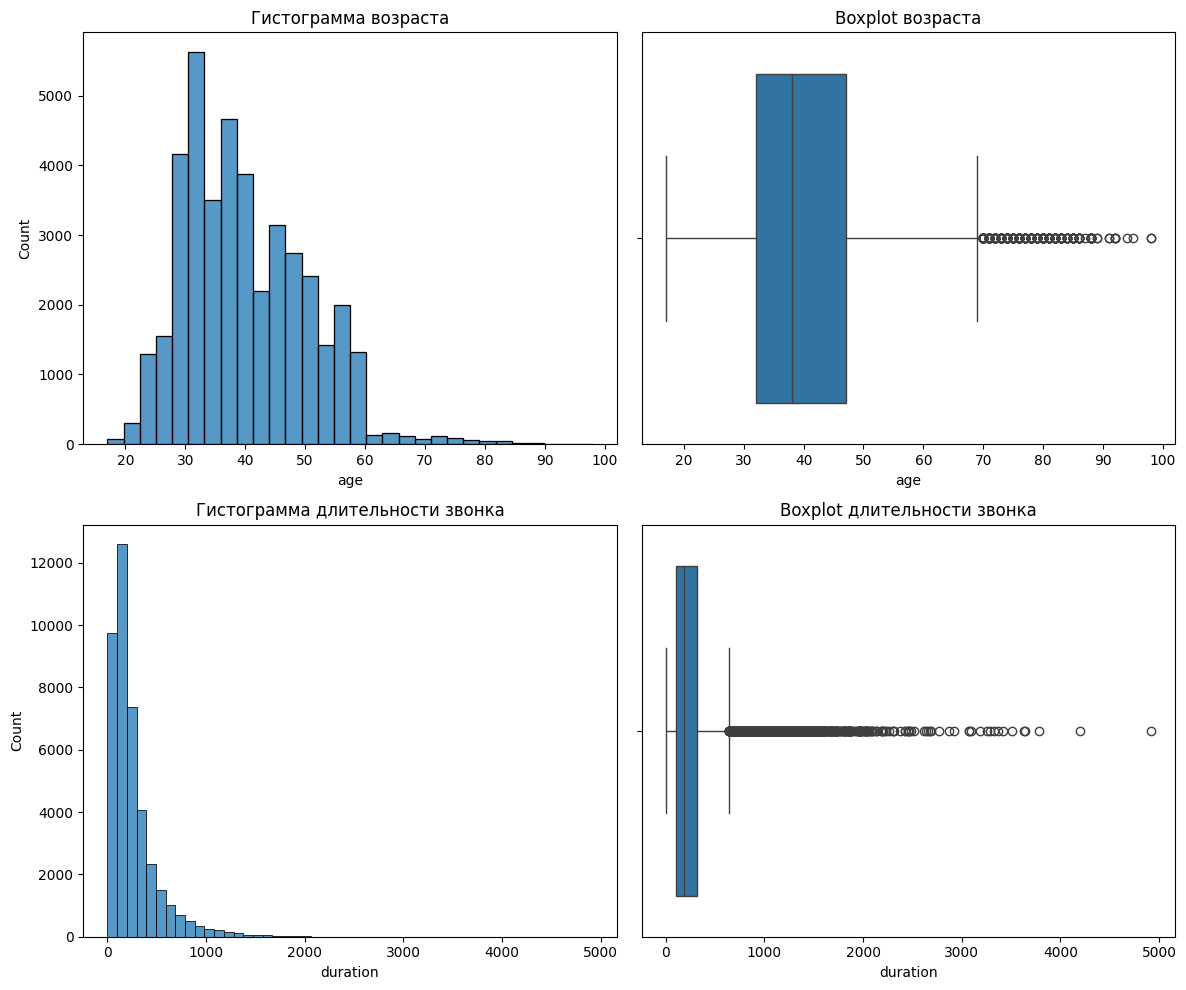


--- Вывод по визуальному анализу ---
Признак age: распределение близко к нормальному, наблюдаются выбросы справа (пожилой возраст).
Признак duration: сильная положительная асимметрия, множество выбросов справа (очень длинные звонки).

Задание 2. Проверка нормальности распределения

--- Описательные характеристики для age и duration ---

age:
  Среднее:     40.02
  Медиана:     38.00
  Стд. откл.:  10.42
  Асимметрия:  0.78
  Эксцесс:     0.79

duration:
  Среднее:     258.29
  Медиана:     180.00
  Стд. откл.:  259.28
  Асимметрия:  3.26
  Эксцесс:     20.25


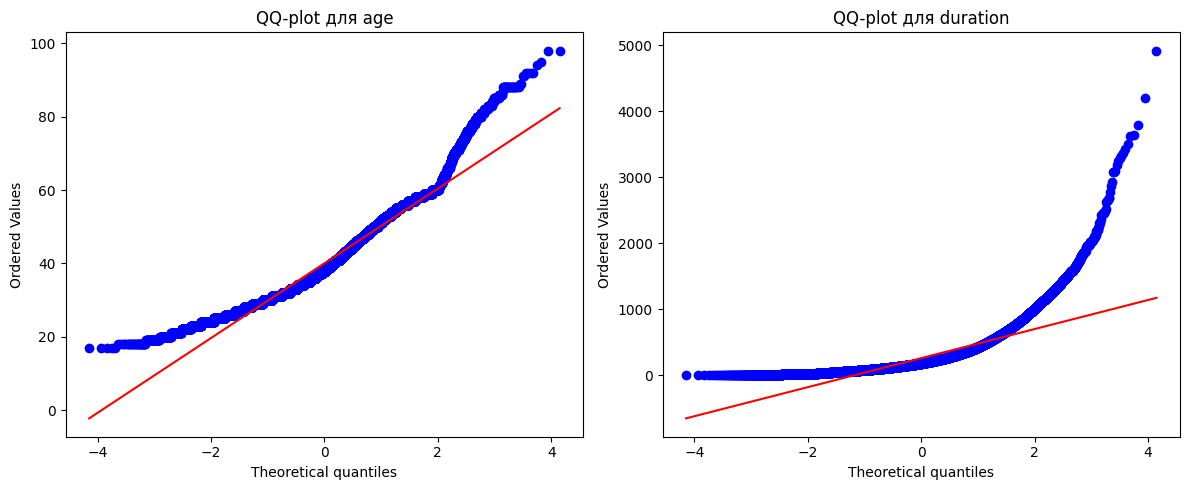


--- Критерий Шапиро-Уилка (на подвыборке 5000) ---
age:      W=0.9614, p-value=1.55e-34
duration: W=0.7362, p-value=6.17e-67

Вывод: для обоих признаков p-value < 0.05, гипотеза о нормальности отвергается.
Однако age визуально ближе к нормальному, его можно использовать для Z-score.

Задание 3. Обнаружение выбросов (признак age)

Метод Z-score (|z|>3):
  Количество выбросов: 369
  Доля выбросов: 0.90%
  Возраст выбросов: [np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(76), np.int64(77), np.int64(78), np.int64(79), np.int64(80), np.int64(81), np.int64(82), np.int64(83), np.int64(84), np.int64(85), np.int64(86), np.int64(87), np.int64(88), np.int64(89), np.int64(91), np.int64(92), np.int64(94), np.int64(95), np.int64(98)]


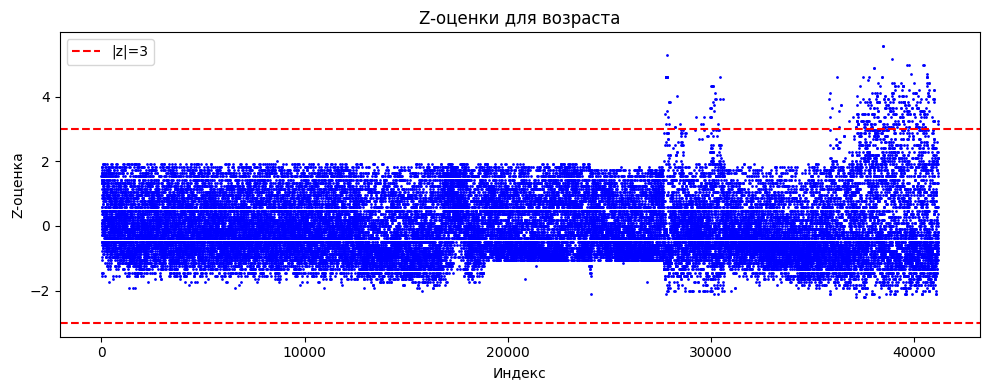


Метод IQR:
  Q1 = 32.0, Q3 = 47.0, IQR = 15.0
  Границы: [9.5, 69.5]
  Количество выбросов: 469
  Доля выбросов: 1.14%
  Возраст выбросов: [np.int64(70), np.int64(71), np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(76), np.int64(77), np.int64(78), np.int64(79), np.int64(80), np.int64(81), np.int64(82), np.int64(83), np.int64(84), np.int64(85), np.int64(86), np.int64(87), np.int64(88), np.int64(89), np.int64(91), np.int64(92), np.int64(94), np.int64(95), np.int64(98)]

--- Сравнение методов ---
Z-score выявил 369 выбросов (возраст > 71.3 или < 8.8)
IQR выявил 469 выбросов (возраст > 69.5 или < 9.5)
Вывод: IQR даёт более широкий список выбросов, включая умеренно пожилых клиентов. Z-score строже.

Задание 4. Метод локальной плотности (k ближайших соседей)

--- Метрика: euclidean ---
k=5: порог=0.040, аномалий=2060 (5.0%)
k=7: порог=0.055, аномалий=2059 (5.0%)
k=9: порог=0.066, аномалий=2060 (5.0%)
k=10: порог=0.070, аномалий=2060 (5.0%)

--- Метрика: manhattan ---
k=5: 

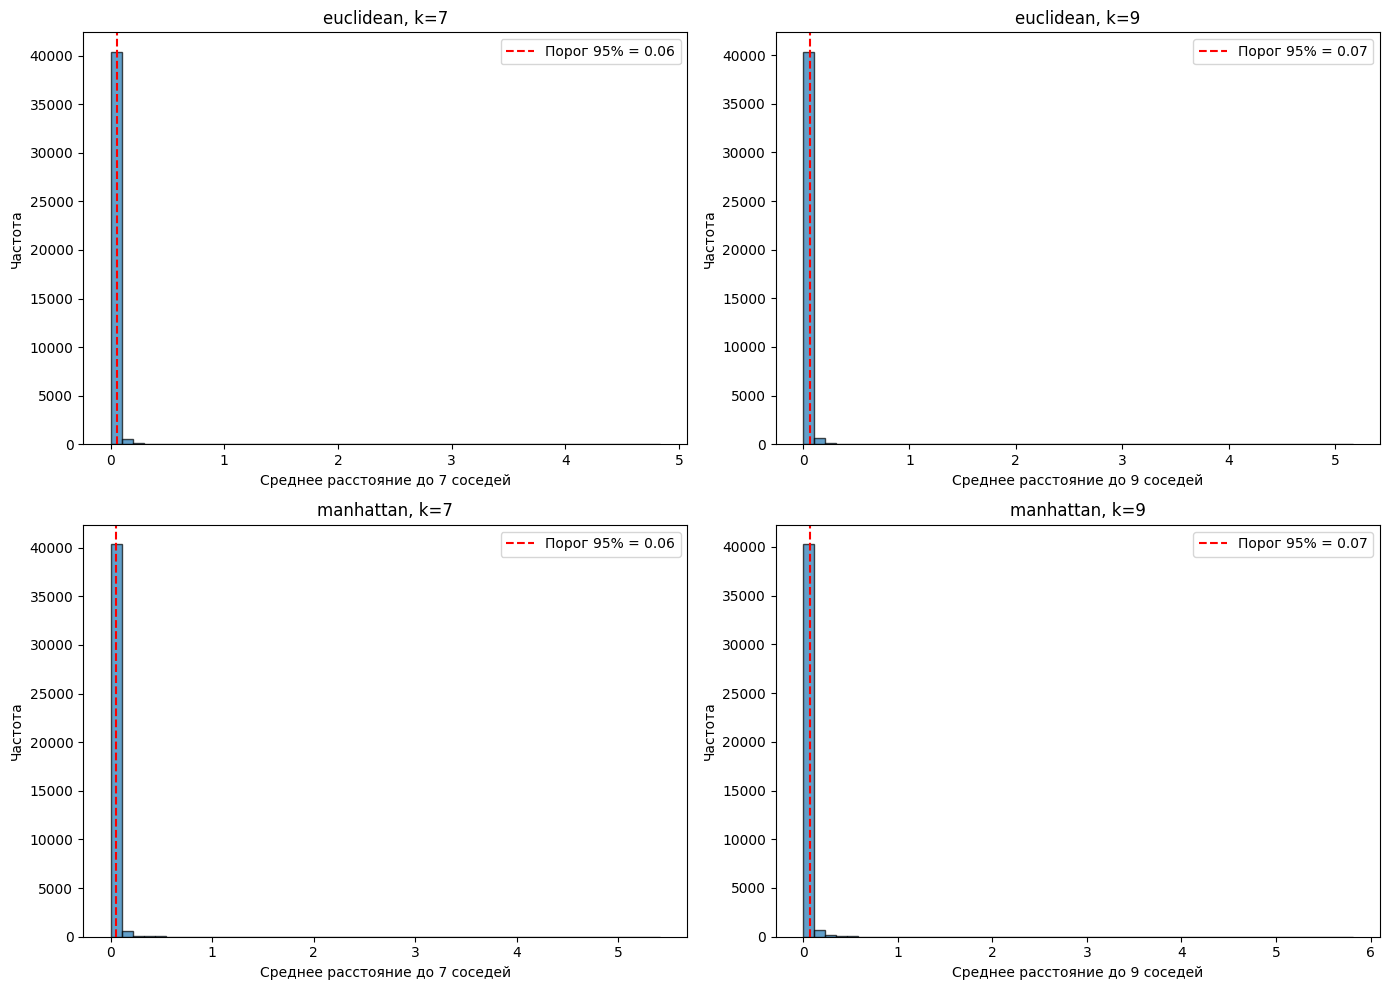

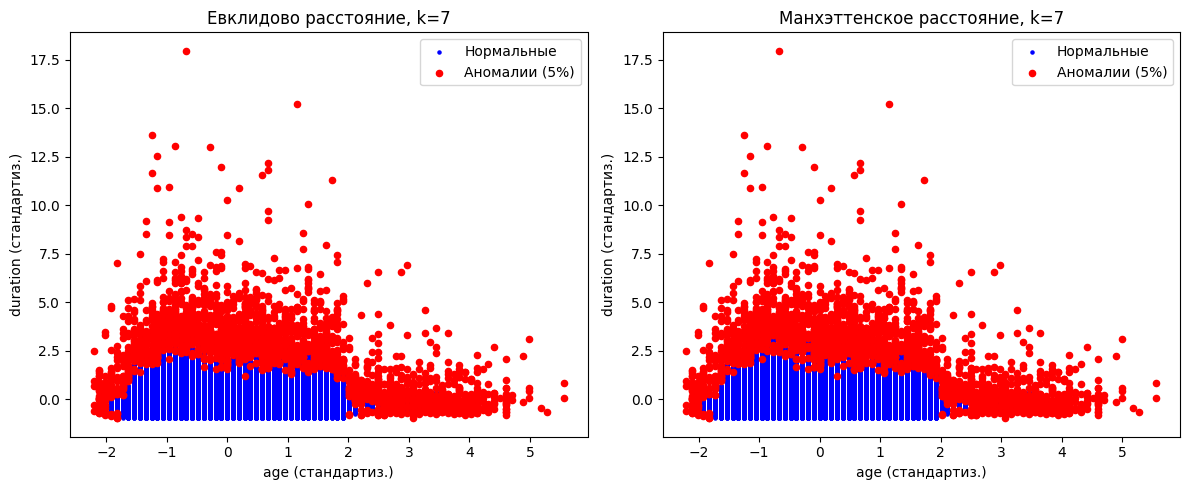


Лабораторная работа выполнена.


In [3]:
# -*- coding: utf-8 -*-
"""Лабораторная работа №2: Обнаружение аномалий"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')
from google.colab import files
uploaded = files.upload()
# ==========================
# Задание 1. Загрузка и профилирование данных
# ==========================
print("="*50)
print("Задание 1. Загрузка и профилирование данных")
print("="*50)

# Загрузка данных (укажите свой путь, если файл не в текущей папке)
try:
    df = pd.read_csv('bank-additional-full.csv', sep=';')
except FileNotFoundError:
    print("Файл не найден. Укажите правильный путь к файлу.")
    # Пример: df = pd.read_csv('/path/to/bank-additional-full.csv', sep=';')
    raise

print("\n--- df.info() ---")
df.info()

print("\n--- df.describe() ---")
print(df.describe())

# Проверка пропусков
print("\n--- Пропуски в данных ---")
print(df.isnull().sum())

# Вывод: пропусков нет, но есть значения 'unknown' в категориальных.

# Визуальный анализ двух признаков: age и duration
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# age
sns.histplot(df['age'], bins=30, ax=axes[0,0])
axes[0,0].set_title('Гистограмма возраста')
sns.boxplot(x=df['age'], ax=axes[0,1])
axes[0,1].set_title('Boxplot возраста')

# duration
sns.histplot(df['duration'], bins=50, ax=axes[1,0])
axes[1,0].set_title('Гистограмма длительности звонка')
sns.boxplot(x=df['duration'], ax=axes[1,1])
axes[1,1].set_title('Boxplot длительности звонка')

plt.tight_layout()
plt.savefig('task1_hist_box.png')
plt.show()

print("\n--- Вывод по визуальному анализу ---")
print("Признак age: распределение близко к нормальному, наблюдаются выбросы справа (пожилой возраст).")
print("Признак duration: сильная положительная асимметрия, множество выбросов справа (очень длинные звонки).")

# ==========================
# Задание 2. Проверка нормальности распределения
# ==========================
print("\n" + "="*50)
print("Задание 2. Проверка нормальности распределения")
print("="*50)

# 2.1 Описательные характеристики
print("\n--- Описательные характеристики для age и duration ---")
for col in ['age', 'duration']:
    print(f"\n{col}:")
    print(f"  Среднее:     {df[col].mean():.2f}")
    print(f"  Медиана:     {df[col].median():.2f}")
    print(f"  Стд. откл.:  {df[col].std():.2f}")
    print(f"  Асимметрия:  {df[col].skew():.2f}")
    print(f"  Эксцесс:     {df[col].kurtosis():.2f}")

# 2.2 Графический анализ (QQ-plot)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
stats.probplot(df['age'], dist="norm", plot=axes[0])
axes[0].set_title('QQ-plot для age')
stats.probplot(df['duration'], dist="norm", plot=axes[1])
axes[1].set_title('QQ-plot для duration')
plt.tight_layout()
plt.savefig('task2_qq.png')
plt.show()

# 2.3 Критерий Шапиро–Уилка (из-за ограничения на 5000, берем подвыборку)
print("\n--- Критерий Шапиро-Уилка (на подвыборке 5000) ---")
np.random.seed(42)
sample_age = np.random.choice(df['age'].dropna(), 5000, replace=False)
sample_dur = np.random.choice(df['duration'].dropna(), 5000, replace=False)

shapiro_age = stats.shapiro(sample_age)
shapiro_dur = stats.shapiro(sample_dur)

print(f"age:      W={shapiro_age.statistic:.4f}, p-value={shapiro_age.pvalue:.2e}")
print(f"duration: W={shapiro_dur.statistic:.4f}, p-value={shapiro_dur.pvalue:.2e}")

print("\nВывод: для обоих признаков p-value < 0.05, гипотеза о нормальности отвергается.")
print("Однако age визуально ближе к нормальному, его можно использовать для Z-score.")

# ==========================
# Задание 3. Обнаружение выбросов статистическими методами
# ==========================
print("\n" + "="*50)
print("Задание 3. Обнаружение выбросов (признак age)")
print("="*50)

# 3.1 Метод Z-score
mean_age = df['age'].mean()
std_age = df['age'].std()
z_scores = (df['age'] - mean_age) / std_age
outliers_z = df[np.abs(z_scores) > 3]
print(f"\nМетод Z-score (|z|>3):")
print(f"  Количество выбросов: {len(outliers_z)}")
print(f"  Доля выбросов: {len(outliers_z)/len(df)*100:.2f}%")
print(f"  Возраст выбросов: {sorted(outliers_z['age'].unique())}")

# Визуализация Z-score
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(z_scores, 'b.', markersize=2)
ax.axhline(y=3, color='r', linestyle='--', label='|z|=3')
ax.axhline(y=-3, color='r', linestyle='--')
ax.set_xlabel('Индекс')
ax.set_ylabel('Z-оценка')
ax.set_title('Z-оценки для возраста')
ax.legend()
plt.tight_layout()
plt.savefig('task3_zscore.png')
plt.show()

# 3.2 Метод IQR
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['age'] < lower_bound) | (df['age'] > upper_bound)]

print(f"\nМетод IQR:")
print(f"  Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}")
print(f"  Границы: [{lower_bound:.1f}, {upper_bound:.1f}]")
print(f"  Количество выбросов: {len(outliers_iqr)}")
print(f"  Доля выбросов: {len(outliers_iqr)/len(df)*100:.2f}%")
print(f"  Возраст выбросов: {sorted(outliers_iqr['age'].unique())}")

# Сравнение
print("\n--- Сравнение методов ---")
print(f"Z-score выявил {len(outliers_z)} выбросов (возраст > {mean_age+3*std_age:.1f} или < {mean_age-3*std_age:.1f})")
print(f"IQR выявил {len(outliers_iqr)} выбросов (возраст > {upper_bound:.1f} или < {lower_bound:.1f})")
print("Вывод: IQR даёт более широкий список выбросов, включая умеренно пожилых клиентов. Z-score строже.")

# ==========================
# Задание 4. Метод локальной плотности
# ==========================
print("\n" + "="*50)
print("Задание 4. Метод локальной плотности (k ближайших соседей)")
print("="*50)

# Подготовка данных: масштабирование
X = df[['age', 'duration']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Параметры
k_values = [5, 7, 9, 10]
metrics = ['euclidean', 'manhattan']
alpha = 5  # верхние 5%
results = {}

for metric in metrics:
    print(f"\n--- Метрика: {metric} ---")
    for k in k_values:
        nn = NearestNeighbors(n_neighbors=k, metric=metric)
        nn.fit(X_scaled)
        distances, indices = nn.kneighbors(X_scaled)
        # среднее расстояние до k соседей (без учёта самой точки)
        avg_dist = np.mean(distances[:, 1:], axis=1)
        threshold = np.percentile(avg_dist, 100 - alpha)
        anomalies = avg_dist > threshold
        results[(metric, k)] = {
            'avg_dist': avg_dist,
            'threshold': threshold,
            'anomalies': anomalies,
            'count': np.sum(anomalies)
        }
        print(f"k={k}: порог={threshold:.3f}, аномалий={results[(metric,k)]['count']} ({np.mean(anomalies)*100:.1f}%)")

# Построение распределения метрики для k=7 (пример)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, metric in enumerate(metrics):
    for j, k in enumerate([7, 9]):
        ax = axes[i, j]
        avg_dist = results[(metric, k)]['avg_dist']
        threshold = results[(metric, k)]['threshold']
        ax.hist(avg_dist, bins=50, edgecolor='black', alpha=0.7)
        ax.axvline(threshold, color='red', linestyle='--', label=f'Порог 95% = {threshold:.2f}')
        ax.set_xlabel('Среднее расстояние до {} соседей'.format(k))
        ax.set_ylabel('Частота')
        ax.set_title(f'{metric}, k={k}')
        ax.legend()
plt.tight_layout()
plt.savefig('task4_distributions.png')
plt.show()

# Визуализация аномалий на scatter plot (для k=7, евклидово)
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
anom_mask = results[('euclidean',7)]['anomalies']
plt.scatter(X_scaled[:,0], X_scaled[:,1], c='blue', s=5, label='Нормальные')
plt.scatter(X_scaled[anom_mask,0], X_scaled[anom_mask,1], c='red', s=20, label='Аномалии (5%)')
plt.xlabel('age (стандартиз.)')
plt.ylabel('duration (стандартиз.)')
plt.title('Евклидово расстояние, k=7')
plt.legend()

plt.subplot(1,2,2)
anom_mask_man = results[('manhattan',7)]['anomalies']
plt.scatter(X_scaled[:,0], X_scaled[:,1], c='blue', s=5, label='Нормальные')
plt.scatter(X_scaled[anom_mask_man,0], X_scaled[anom_mask_man,1], c='red', s=20, label='Аномалии (5%)')
plt.xlabel('age (стандартиз.)')
plt.ylabel('duration (стандартиз.)')
plt.title('Манхэттенское расстояние, k=7')
plt.legend()
plt.tight_layout()
plt.savefig('task4_scatter.png')
plt.show()


print("\n" + "="*50)
print("Лабораторная работа выполнена.")
print("="*50)